In [2]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm
from PIL import Image
from torch.optim import Adam,SGD,lr_scheduler
import matplotlib.pyplot as plt
from torchvision import transforms, models
from utils import DiceLoss, SquarePad, SquarePad255
from Water_Dataset import Water_Dataset
from torch.utils.data import Dataset, Subset, DataLoader,random_split


group_spec={
    'perfe':114,
    'poly+':152,
    'poly-':408,
    'rough':618,
    'bbox_msk':1113,
    'sam_box':1113,
    'point_msk':int(114*9.76168224/0.96729)
}


mult_spec={
    'perfe':[1,2,4,8,16,32],
    'poly+':[1,2,4,8,16,3648/group_spec['poly+']],
    'poly-':[1,2,4,8,3648/group_spec['poly-']],
    'rough':[1,2,4,3648/group_spec['rough']],
    'bbox_msk':[1,2,3648/group_spec['bbox_msk']],
    'sam_box':[1,2,3648/group_spec['sam_box']],
    'point_msk':[1,2,3648/group_spec['point_msk']]
}


base_epoch = 100
pretrained = 'pb'
label_type = 'sam_box' #perfe, poly+, poly-, rough, bbox_msk
assert pretrained in ['pb','fb']
assert label_type in ['perfe','poly+','poly-','rough','bbox_msk','sam_box']



img_preprocess = transforms.Compose([
    transforms.RandomEqualize(),
    transforms.ColorJitter(brightness=.5, hue=.3),
#     SquarePad(),
    transforms.CenterCrop(512),
#     transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],\
                         std=[0.229, 0.224, 0.225]),
])
msk_preprocess = transforms.Compose([
#     SquarePad255(),
#     transforms.Resize(256, interpolation=transforms.InterpolationMode.NEAREST),
    transforms.CenterCrop(512),
])


num_classes = 2
loss_fn = nn.CrossEntropyLoss(ignore_index=255) #DiceLoss()

In [2]:
for label_type in ['point_msk']:#['perfe','poly+','poly-','rough','bbox_msk','sam_box']:
    DATA = Water_Dataset('/data/Water/','trainval',label_type, img_preprocess, msk_preprocess)
    group_size = group_spec[label_type]
    for multiplicity in mult_spec[label_type][2:]:

        model = models.segmentation.deeplabv3_resnet50(num_classes=num_classes)

        #if randomly init, randomly re-initilaize backbone
        model = nn.DataParallel(model).cuda()
        #short for DeepLab-VOC-{label_type}-m{multiplicity}
        model_name = f'DLab_H{label_type}_m{round(multiplicity,2)}_{pretrained}' 

        train_subset = Subset(DATA, list(range(round((group_size*multiplicity)))))
        val_subset = Subset(DATA, list(range(3648, len(DATA))))
        train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, drop_last=True,num_workers=16,pin_memory=True)
        val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, drop_last=True,num_workers=16,pin_memory=True)

        epochs=round(base_epoch*(1.5**np.log2(3648/len(train_subset))))

        min_loss = np.inf
        fin_epoch = 0

        if pretrained == 'pb':
            optimizer = Adam(model.parameters(),lr=1e-3,weight_decay=1e-6)
            try:
                checkpoint = torch.load(f'/data/model_checkpoints/{model_name}.pth')
                fin_epoch = checkpoint['fin_epoch']
                min_loss = checkpoint['min_loss']
                model.load_state_dict(checkpoint['model_state_dict'])
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            except:
                print(f'new model training {model_name}')

        elif pretrained == 'fb':
            optimizer = SGD(model.module.classifier.parameters(),lr=1e-2,momentum=0.9,weight_decay=5e-4)
            scheduler = lr_scheduler.MultiStepLR(optimizer, milestones=[3000*i for i in range(1,5)], gamma=0.1)
            try:
                checkpoint = torch.load(f'/data/model_checkpoints/{model_name}.pth')
                fin_epoch = checkpoint['fin_epoch']
                min_loss = checkpoint['min_loss']
                model.load_state_dict(checkpoint['model_state_dict'])
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                print('scheduler loaded')
            except:
                print(f'new model training {model_name}')

        else:
            assert False

        pbar = tqdm(range(epochs-fin_epoch))
        for e in pbar:

            train_loss = 0
            val_loss = 0
            model.train()
            for idx,(X,y) in enumerate(train_loader):

                y = y.squeeze()

                optimizer.zero_grad()
                yhat = model(X.contiguous().cuda())['out']
                loss = loss_fn(yhat,y.cuda())
                loss.backward()
                optimizer.step()
                if pretrained == 'fb':
                    scheduler.step()
                train_loss += loss.item()
            train_loss /= (idx+1)

            model.eval()
            with torch.no_grad():
                class_intersect = np.zeros((num_classes,),dtype='float')
                class_union= np.zeros((num_classes,),dtype='float')

                for idx,(X,y) in enumerate(val_loader):

                    y = y.flatten().cuda()
                    yhat = model(X.contiguous().cuda())['out']
                    yhat_lab = torch.argmax(yhat, dim=1).flatten()
                    yhat_lab[y==255] = 255

                    for j in range(num_classes):

                        y_bi = y == j
                        yhat_bi = yhat_lab == j
                        I = (y_bi * yhat_bi).sum()
                        U = y_bi.sum() + yhat_bi.sum() - I
                        assert I <= U
                        class_intersect[j] += I.item()
                        class_union[j] += U.item()
                IOUs = class_intersect/class_union
                val_loss=-np.mean(IOUs)
    #             print('Train loss',train_loss, 'IOU', -val_loss)

            pbar.set_description(f'DSC loss: train_mean={train_loss}|val={val_loss}')

            if e +fin_epoch+1 <10:
                continue

            if val_loss < min_loss:
                min_loss = val_loss
                to_save ={
                    'min_loss': min_loss,
                    'fin_epoch': e+fin_epoch+1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict()}
                if pretrained=='fb':
                    to_save['scheduler_state_dict']= scheduler.state_dict()

                torch.save(to_save, f'/data/model_checkpoints/{model_name}.pth')  

DSC loss: train_mean=0.05624489533600577|val=-0.5955806149634169: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [1:38:16<00:00, 111.26s/it]


In [3]:
#Version 1: 512 by 512 patch
pretrained='pb'

performance={}
num_classes=2

test_preprocess = transforms.Compose([
    SquarePad(),
    transforms.CenterCrop(512),
#     transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],\
                         std=[0.229, 0.224, 0.225]),
])
tmsk_preprocess = transforms.Compose([
    SquarePad(),
    transforms.CenterCrop(512),
#     transforms.Resize(256, interpolation=transforms.InterpolationMode.NEAREST),
])

test_loader = DataLoader(Water_Dataset('/data/Water/','test',label_type, test_preprocess, tmsk_preprocess), 
                         batch_size=32, num_workers=16)


for label_type in ['point_msk']: #mult_spec.keys():
    performance[label_type]={}
    
    for multiplicity in mult_spec[label_type]:
        
        #The resnet weight is loaded by default
        model = models.segmentation.deeplabv3_resnet50(num_classes=num_classes)
        #if randomly init, randomly re-initilaize backbone
        model = nn.DataParallel(model).cuda()
        
        model_name = f'DLab_H{label_type}_m{round(multiplicity,2)}_{pretrained}'  
        checkpoint = torch.load(f'/data/model_checkpoints/{model_name}.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        
        model.eval()
        print(f'Working on label_type={label_type}:{round(multiplicity,2)}')
        class_intersect = np.zeros((num_classes, ),dtype='float')
        class_union = np.zeros((num_classes, ),dtype='float')
    
        with torch.no_grad():
            for idx,(X,y) in enumerate(test_loader):
#                 assert False
                y = y.cuda().contiguous().flatten()
                
                yhat = model(X.contiguous().cuda())['out']
                yhat_lab = torch.argmax(yhat, dim=1).flatten()
                yhat_lab[y == 255] = 255

                for j in range(num_classes):

                    y_bi = y == j
                    yhat_bi = yhat_lab == j
                    I = ((y_bi * yhat_bi).sum()).item()
                    U = (y_bi.sum() + yhat_bi.sum() - I).item()
                    assert I <= U
                    class_intersect[j] += I
                    class_union[j] += U
            
        performance[label_type][multiplicity]=(class_intersect, class_union)
        
# np.save(f'Water_Inter-Union_{pretrained}3', performance)


Working on label_type=point_msk:1
Working on label_type=point_msk:2
Working on label_type=point_msk:3.17


In [ ]:
'/data/model_checkpoints/DLab_Hpoin'

In [9]:
performance

{'point_msk': {1: (array([47239920.,  3625573.]),
   array([54570395., 10956048.])),
  2: (array([47493875.,  5076247.]), array([53119721., 10702093.])),
  3.172173913043478: (array([47705872.,  4719219.]),
   array([53476749., 10490096.]))}}

In [4]:
# for i in [1,2,3.2776280323450133]:
for i in [1,2,3.172173913043478]:
    a,b = performance['point_msk'][i]
    print(a/b)

[0.88120829 0.4081831 ]
[0.88531798 0.38609436]
[0.89586905 0.47280737]


In [10]:
#Old testng method (Version 0)
pretrained='pb'

performance={}
num_classes=2

test_preprocess = transforms.Compose([
    SquarePad(),
#     transforms.CenterCrop(256+128),
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],\
                         std=[0.229, 0.224, 0.225]),
])
tmsk_preprocess = transforms.Compose([
    SquarePad(),
#     transforms.CenterCrop(256+128),
    transforms.Resize(256, interpolation=transforms.InterpolationMode.NEAREST),
])

test_loader = DataLoader(Water_Dataset('/data/Water/','test',label_type, test_preprocess, tmsk_preprocess), 
                         batch_size=32, num_workers=16)


for label_type in mult_spec.keys():
    performance[label_type]={}
    
    for multiplicity in mult_spec[label_type]:
        
        #The resnet weight is loaded by default
        model = models.segmentation.deeplabv3_resnet50(num_classes=num_classes)
        #if randomly init, randomly re-initilaize backbone
        model = nn.DataParallel(model).cuda()
        
        model_name = f'DLab_H{label_type}_m{round(multiplicity)}_{pretrained}'  
        checkpoint = torch.load(f'/data/model_checkpoints/{model_name}.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        
        model.eval()
        print(f'Working on label_type={label_type}:{round(multiplicity)}')
        class_intersect = np.zeros((num_classes, ),dtype='float')
        class_union = np.zeros((num_classes, ),dtype='float')
    
        with torch.no_grad():
            for idx,(X,y) in enumerate(test_loader):
#                 assert False
                y = y.cuda().contiguous().flatten()
                
                yhat = model(X.contiguous().cuda())['out']
                yhat_lab = torch.argmax(yhat, dim=1).flatten()
                yhat_lab[y == 255] = 255

                for j in range(num_classes):

                    y_bi = y == j
                    yhat_bi = yhat_lab == j
                    I = ((y_bi * yhat_bi).sum()).item()
                    U = (y_bi.sum() + yhat_bi.sum() - I).item()
                    assert I <= U
                    class_intersect[j] += I
                    class_union[j] += U
            
        performance[label_type][multiplicity]=(class_intersect, class_union)
        
np.save(f'Water_Inter-Union_{pretrained}3', performance)


Working on label_type=perfe:1
Working on label_type=perfe:2
Working on label_type=perfe:4
Working on label_type=perfe:8
Working on label_type=perfe:16
Working on label_type=perfe:32
Working on label_type=poly+:1
Working on label_type=poly+:2
Working on label_type=poly+:4
Working on label_type=poly+:8
Working on label_type=poly+:16
Working on label_type=poly+:24
Working on label_type=poly-:1
Working on label_type=poly-:2
Working on label_type=poly-:4
Working on label_type=poly-:8
Working on label_type=poly-:9
Working on label_type=rough:1
Working on label_type=rough:2
Working on label_type=rough:4
Working on label_type=rough:6
Working on label_type=bbox_msk:1
Working on label_type=bbox_msk:2
Working on label_type=bbox_msk:3


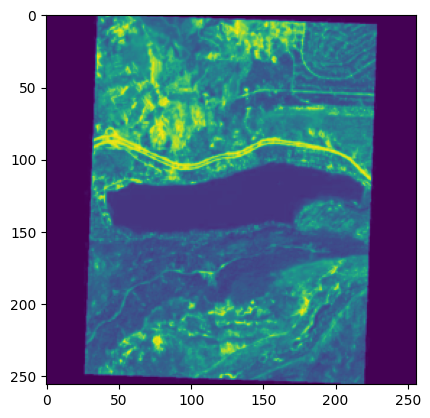

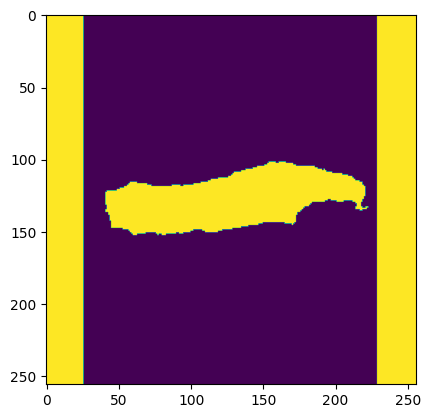

In [8]:
plt.imshow(X[0,0])
plt.show()
plt.imshow(y[0])

In [ ]:
#Fine tuning
label_type='perfe'
for multiplicity in mult_spec[label_type]:
    #The resnet weight is loaded by default
    if pretrained !='fb':
        break
    model = models.segmentation.deeplabv3_resnet50(num_classes=2)

    #if randomly init, randomly re-initilaize backbone
    model = nn.DataParallel(model).cuda()
    #short for DeepLab-VOC-{label_type}-m{multiplicity}
    model_name = f'DLab_H{label_type}_m{round(multiplicity)}_{pretrained}' 
    
    train_subset = Subset(DATA, list(range(round((group_size*multiplicity)))))
    val_subset = Subset(DATA, list(range(3648-200, len(DATA))))
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, drop_last=True)
    
    min_loss = np.inf
    fin_epoch = 0
    
    optimizer = SGD([{'params': model.module.classifier.parameters(),'lr':1e-5,'momentum':0.9,'weight_decay':5e-4},
                     {'params':model.module.backbone.parameters(),'lr':1e-5,'momentum':0.9}])
    
    
    try:
        checkpoint = torch.load(f'/data/model_checkpoints/{model_name}.pth')
        fin_epoch = checkpoint['fin_epoch']
        min_loss = checkpoint['min_loss']
        model.load_state_dict(checkpoint['model_state_dict'])
#         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    except:
        print(f'new model training {model_name}')

    for e in range(5):
        train_loss = 0
        val_loss = 0
        model.train()
        for idx,(X,y) in enumerate(tqdm(train_loader)):
            with torch.no_grad():
                valid_loc = (y != 255)
                y = y*valid_loc

            y = y.squeeze()

            optimizer.zero_grad()
            yhat = model(X.contiguous().cuda())['out']
            loss0 = loss_fn(yhat,y.cuda())
            loss = (loss0*valid_loc.cuda()).mean()
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
        train_loss /= (idx+1)

        model.eval()
        with torch.no_grad():
            class_intersect = np.zeros((2,),dtype='float')
            class_union= np.zeros((2,),dtype='float')
            for idx,(X,y) in enumerate(val_loader):
                y = y.flatten()
    #             out = res50(X.contiguous().cuda())['out']
    #             yhat = head(out)
                yhat = model(X.contiguous().cuda())['out']
                yhat_lab = torch.argmax(yhat.cpu(), dim=1).flatten()
                skip_id = np.argwhere(y == 255)
                yhat_lab[skip_id] = 255

                for j in range(2):

                    y_bi = y == j
                    yhat_bi = yhat_lab == j
                    I = (y_bi * yhat_bi).sum()
                    U = y_bi.sum() + yhat_bi.sum() - I
                    assert I <= U
                    class_intersect[j] += I
                    class_union[j] += U
            IOUs = class_intersect/class_union
            val_loss=-np.mean(IOUs)
            print('Train loss',train_loss, 'IOU', -val_loss)


        if val_loss < min_loss:
            min_loss = val_loss
            torch.save({
                'min_loss': min_loss,
                'fin_epoch': fin_epoch,
                'fine_tune': e+1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),},f'{model_name}.pth') 

  0%|                                                                                                                                                                                   | 0/7 [00:00<?, ?it/s]

Train loss 0.11396992313010353 IOU 0.7443919678826482


  0%|                                                                                                                                                                                   | 0/7 [00:00<?, ?it/s]

Train loss 0.11304742097854614 IOU 0.7417944534879679


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:06<00:00,  1.02it/s]


...

  0%|                                                                                                                                                                                 | 0/228 [00:00<?, ?it/s]

Train loss 0.17319999769199312 IOU 0.8632881500835078


  0%|                                                                                                                                                                                 | 0/228 [00:00<?, ?it/s]

Train loss 0.17349326287053132 IOU 0.8620706469055317


 83%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                            | 189/228 [03:15<00:45,  1.16s/it]